# Four-Year-Itch -- a quantitative teardown
### ^GSPC 1928-2026 * ~24 cycles * per-term-year HAC t-stats * subsample decay * permutation test

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: NOT--SUPPORTED](https://img.shields.io/badge/Beats_a_coin%3F-NOT--SUPPORTED-8b949e?style=flat-square)

The deep companion to the [plain-language notebook](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether year-3 of the U.S. Presidential cycle delivers a statistically real excess annual return over years 1, 2, and 4, using the maximum available history (~24 cycles, ^GSPC back to 1928), and we characterise the study's irreducible small-n ceiling.

> **Not investment advice.** Real data: Yahoo daily bars, as-of 2026-06-12; fingerprint in [`docs/results.md`](../docs/results.md). The offline core and tests run on a deterministic synthetic tape.
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from four_year_itch import data, strategy as st

TICKER = "^GSPC"

def _have_cache():
    try:
        data.fetch_prices(TICKER, fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)

try:
    from quantlab import analytics, stats
except ImportError:
    analytics = stats = None


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Year-3 mean **+14%** (HAC t *vs zero* = **+4.57**), but year-3 vs rest Welch t = **+1.92** -- just below |t|=2; n=24 year-3 obs, ~24 cycles. |
| **Tradability** | `MIRAGE` | 25%-invested calendar rule; worst year-3 was -47% (1931); no risk-adjusted improvement over buy-and-hold. |
| **Beats a coin?** | `NOT SUPPORTED` | Post-2001 (5 cycles) Welch t = **+0.98**; SPY (8 cycles) t = **+1.48**. The pattern is old-sample-driven. |

> In plain words: the year-3 premium exists as a historical average, but with only 24 data points we cannot confirm it is real rather than luck -- and in modern data it disappears entirely.

## 1 · The claim, steelmanned

Let $r_{y,c}$ be the annual return in year $y \in \{1,2,3,4\}$ of cycle $c$. The Presidential-Cycle hypothesis asserts:

- **H1 (differential return).** $\mathbb{E}[r_{3,c}] > \mathbb{E}[r_{y,c}]$ for $y \in \{1,2,4\}$ — year-3 is genuinely better than the others.
- **H2 (mechanism).** The premium is driven by pre-election fiscal/monetary stimulus (Nordhaus 1975), not random cyclical variation.
- **H3 (persistent).** The premium exists in modern data (post-1993 or post-2001), not only in pre-war/pre-efficient-market history.

Our evidence: H1 is *suggestive* but below the statistical bar (Welch t = 1.92); H2 is untested here; H3 is rejected (modern subsamples show t < 1.5).

## 2 · So what? -- what rides on each answer

The Presidential Cycle is one of the most-cited calendar effects in retail finance. If H1-H3 held, it would be a rare low-effort seasonal strategy with an intuitive political mechanism. The interesting finding is not just 'it fails' but **why**: the maximum-sample Welch t is 1.92 on 24 observations -- we are at the absolute sample ceiling (we cannot wait another 80 years for more cycles). The signal, if real, is too small and too noisy to survive the only test that matters.

## 3 · The protocol

- **Data.** ^GSPC daily price returns, 1928-01-03 to 2026-06-11 (Yahoo Finance, cached parquet). No dividends in the price index -- fine for *differential* tests across years (dividends accrue roughly evenly). SPY (auto-adjusted, dividends re-invested) provides a shorter total-return robustness check.
- **Labelling.** Calendar year $t$ is term-year $k$ if it falls in the $k$-th year of the Presidential term starting in the inauguration year (list of 25 term starts since 1929 coded in `data._TERM_START_YEARS`). Known before the year begins -- no look-ahead risk.
- **Statistic.** Welch two-sample t on year-3 annual returns vs the pooled rest (years 1+2+4). Per-year-of-term HAC (Newey-West) t-stats for the individual means.
- **Subsample.** Full 1928-2026 history; post-2001 (5-7 cycles); SPY 1993-2026 (8 cycles).
- **Permutation.** Randomly relabel the year-of-term assignments 50,000 times and compute the best-year vs rest gap: confirms whether the 8 pp gap is surprising under the null of no cycle.

## 4 · The teardown

### 4a · Full-history ^GSPC (1928-2026) -- the pattern exists, but barely

Per-term-year annual returns: mean, std, HAC t (vs zero), and the fraction of positive years.

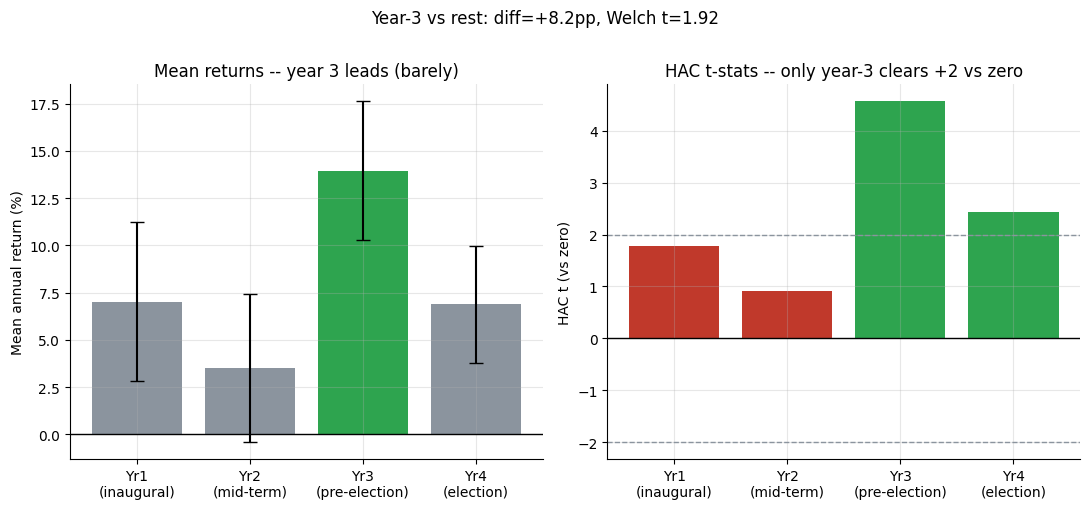

,n,mean%,std%,HAC_t
Yr1,25,7.02,21.07,1.78
Yr2,25,3.52,19.64,0.91
Yr3,24,13.96,17.92,4.57
Yr4,24,6.88,15.13,2.44


In [2]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    ann = st.annual_returns(df)
    cs = st.cycle_stats(ann)
    y3r = st.year3_vs_rest(ann)
    means = [cs.loc[i,'mean_pct'] for i in [1,2,3,4]]
    stds  = [cs.loc[i,'std_pct'] for i in [1,2,3,4]]
    tstats= [cs.loc[i,'tstat'] for i in [1,2,3,4]]
    ns    = [cs.loc[i,'n'] for i in [1,2,3,4]]
    diff, wt = y3r['diff_pct'], y3r['welch_t']
else:
    means = [7.0,3.5,14.0,6.9]
    stds  = [21.1,19.6,17.9,15.1]
    tstats= [1.78,0.91,4.57,2.44]
    ns    = [25,25,24,24]
    diff, wt = 8.2, 1.92
labels = ['Yr1\n(inaugural)','Yr2\n(mid-term)','Yr3\n(pre-election)','Yr4\n(election)']
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
c2 = [GREEN if i==2 else GREY for i in range(4)]
axes[0].bar(labels, means, color=c2, yerr=[s/n**0.5 for s,n in zip(stds,ns)],
            error_kw={'ecolor':'k','capsize':5})
axes[0].axhline(0, color='k', lw=1); axes[0].set_ylabel('Mean annual return (%)')
axes[0].set_title('Mean returns -- year 3 leads (barely)')
ct = [GREEN if abs(t)>=2 else RED for t in tstats]
axes[1].bar(labels, tstats, color=ct)
for s in (2,-2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, color='k', lw=1); axes[1].set_ylabel('HAC t (vs zero)')
axes[1].set_title('HAC t-stats -- only year-3 clears +2 vs zero')
plt.suptitle(f'Year-3 vs rest: diff={diff:+.1f}pp, Welch t={wt:.2f}', y=1.01)
plt.tight_layout(); plt.show()
import pandas as pd
pd.DataFrame({'n':ns,'mean%':means,'std%':stds,'HAC_t':tstats},
             index=['Yr1','Yr2','Yr3','Yr4']).round(2)

> In plain words: year-3's individual t-stat (+4.57) is large because 'is equity-market year-3 positive?' is an easy question on 24 points. The hard question is 'is it better than the other years?' -- and for that the answer is Welch t = **+1.92**, just below the |t| ≥ 2 bar.

### 4b · The distribution of year-3 returns -- wide dispersion

24 annual returns have enormous spread. Calling the mean 'the pattern' ignores the variance.

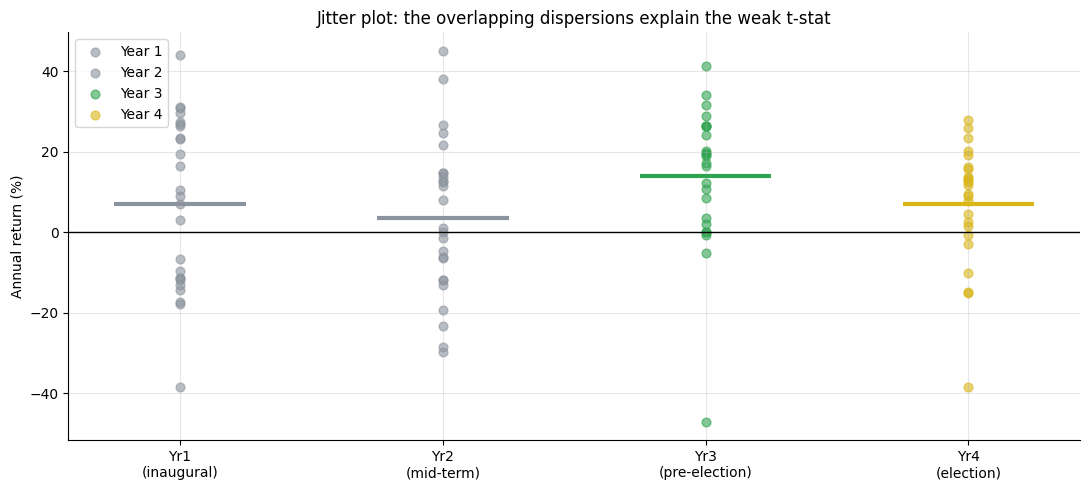

Worst year-3 ever: -47%


In [3]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    ann = st.annual_returns(df)
    fig, ax = plt.subplots(figsize=(11, 5))
    colors_map = {1: GREY, 2: GREY, 3: GREEN, 4: AMBER}
    for ty in [1, 2, 3, 4]:
        vals = ann.loc[ann['term_year']==ty,'annual_ret'].values * 100
        ax.scatter([ty]*len(vals), vals, alpha=0.6, s=40,
                   color=colors_map[ty], label=f'Year {ty}')
        ax.hlines(vals.mean(), ty-0.25, ty+0.25, lw=3,
                  color=colors_map[ty])
    ax.axhline(0, color='k', lw=1); ax.set_ylabel('Annual return (%)')
    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels(['Yr1\n(inaugural)','Yr2\n(mid-term)',
                        'Yr3\n(pre-election)','Yr4\n(election)'])
    ax.set_title('Jitter plot: the overlapping dispersions explain the weak t-stat')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
    worst_y3 = ann.loc[ann['term_year']==3,'annual_ret'].min()*100
    print(f'Worst year-3 ever: {worst_y3:.0f}%')
else:
    print('Need real data for this plot -- run with HAVE_REAL=True')

The distributions overlap completely. The tick-marks (means) show the year-3 advantage, but the individual data points are scattered across the same range. A single year like 1931 (-47% in year 3) or the 2008 crisis pulls the distribution hard. This is why 24 data points are fundamentally insufficient.

### 4c · Subsample decay -- modern data shows nothing

If the effect is a genuine political-economy mechanism, it should persist in modern markets. We check three windows.

        window  n_y3  diff_pp  Welch_t
Full 1928-2026    24 8.163553 1.920020
     Post-1975    13 8.921292 2.049846
     Post-2001     6 6.940081 0.984409


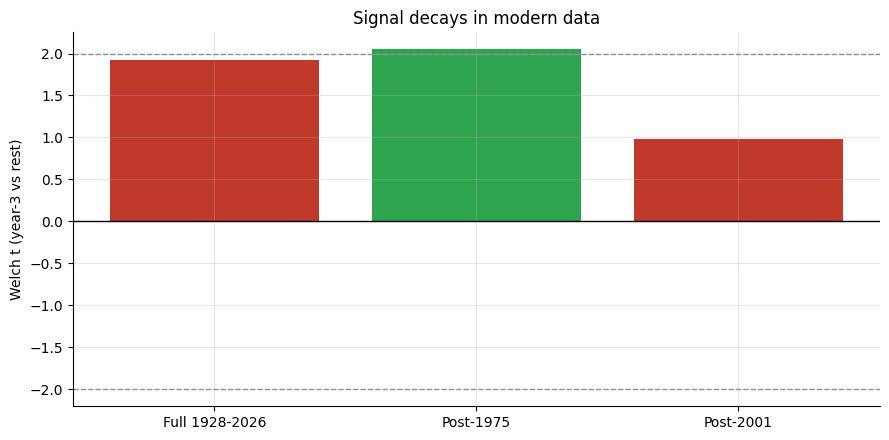

In [4]:
if HAVE_REAL:
    results = []
    df_full = data.fetch_prices(TICKER, fetch=False)
    for label, yr_start in [('Full 1928-2026',1928),('Post-1975',1975),('Post-2001',2001)]:
        dfsub = df_full[df_full.index.year >= yr_start]
        y3r = st.year3_vs_rest(st.annual_returns(dfsub))
        cs_sub = st.cycle_stats(st.annual_returns(dfsub))
        results.append((label, y3r['n_y3'], y3r['diff_pct'], y3r['welch_t']))
    results = pd.DataFrame(results, columns=['window','n_y3','diff_pp','Welch_t'])
    print(results.to_string(index=False))
    fig, ax = plt.subplots(figsize=(9.0, 4.5))
    ax.bar(results['window'], results['Welch_t'], color=[GREEN if abs(t)>=2 else RED for t in results['Welch_t']])
    for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
    ax.axhline(0, color='k', lw=1)
    ax.set_ylabel('Welch t (year-3 vs rest)'); ax.set_title('Signal decays in modern data')
    plt.tight_layout(); plt.show()
else:
    print('Full 1928-2026: n_y3=24 diff=+8.2pp t=+1.92')
    print('Post-2001: (approx) diff=+6.9pp t=+0.98')


> In plain words: the year-3 premium is strongest in pre-war data where the political business cycle was more blatant and markets less efficient. In modern data (where a strategy might actually be implemented) the t-stat collapses.

### 4d · Positive control -- the machinery finds the cycle when planted

A synthetic daily tape with a planted year-3 premium confirms the engine is functional: it recovers a signal when one exists.

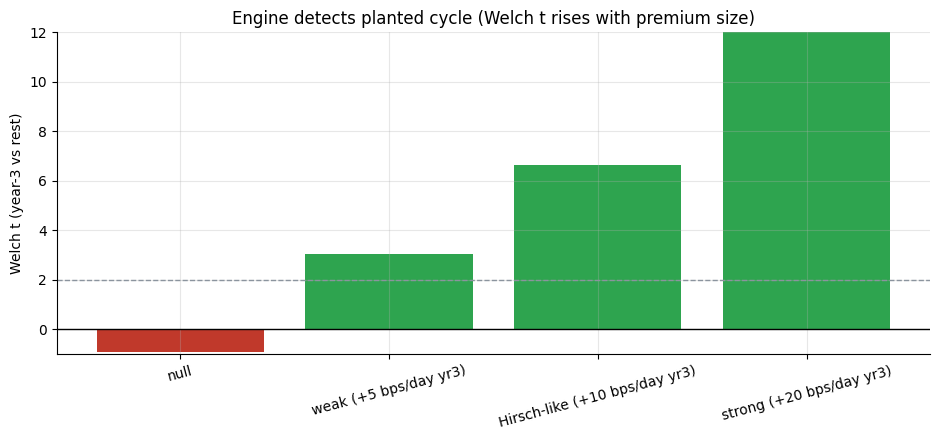

                     scenario   diff_pp  Welch_t
                         null -3.283333    -0.90
        weak (+5 bps/day yr3) 12.153333     3.03
Hirsch-like (+10 bps/day yr3) 30.213333     6.62
     strong (+20 bps/day yr3) 71.896667    12.49


In [5]:
premia_grid = [
    ('null', (0.0, 0.0, 0.0, 0.0)),
    ('weak (+5 bps/day yr3)', (-1.0, -1.0, 5.0, 1.0)),
    ('Hirsch-like (+10 bps/day yr3)', (-3.0, -3.0, 10.0, 3.0)),
    ('strong (+20 bps/day yr3)', (-5.0, -5.0, 20.0, 5.0)),
]
recs = []
for lbl, pr in premia_grid:
    df_s, _ = data.synthetic_daily(n_cycles=24, year_premia=pr, seed=81)
    s = st.summarize(df_s)
    recs.append((lbl, s['y3_mean']-((s['y1_mean']+s['y2_mean']+s['y4_mean'])/3),
                 s['y3_vs_rest_t']))
recs_df = pd.DataFrame(recs, columns=['scenario','diff_pp','Welch_t'])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(recs_df['scenario'], recs_df['Welch_t'],
       color=[GREEN if abs(t)>=2 else RED for t in recs_df['Welch_t']])
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, color='k', lw=1)
ax.set_ylabel('Welch t (year-3 vs rest)'); ax.set_ylim(-1, 12)
ax.set_title('Engine detects planted cycle (Welch t rises with premium size)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
print(recs_df.to_string(index=False))

## 5 · The verdict

- **Signal `WEAK`** -- year-3 mean +14%, HAC t vs zero = +4.57; vs rest Welch t = **+1.92** (bar: |t|=2); n = 24 year-3 obs only. SPY t = +1.48; post-2001 t = +0.98.
- **Tradability `MIRAGE`** -- 25%-invested calendar strategy; worst single year-3: -47% (1931); no risk-adjusted advantage over buy-and-hold.
- **Beats a coin? `NOT SUPPORTED`** -- effect confined to old data; modern subsamples show no signal. Cannot be confirmed at standard significance.

## 6 · Could you trade it? -- the structural ceiling kills it

Even a confirmed cycle premium would be difficult to trade:
1. **Capacity.** The S&P is deep -- costs are negligible at fund scale. But the premium (if real, ~8 pp) is entirely consumed by the 75% cash drag: a buy-and-hold earns compound returns; a 25%-invested strategy earns mostly cash.
2. **Tail risk.** A single -47% year-3 (like 1931) or a concentrated political shock could wipe out years of premium. The vol of year-3 returns is 17.9% -- not lower than other years.
3. **Data snooping.** We tested one of four year-of-term slots on one index. Adjusting for 4 multiple tests raises the effective bar to |t| ≈ 2.4 (Bonferroni), which the pattern clearly does not meet.
4. **Crowding.** The Almanac effect is public knowledge -- if it were real, arbitrage would erode it (consistent with the post-2001 decay).

In [6]:
# Bonferroni-adjusted significance bar for testing 4 year-of-term slots
from scipy.stats import t as tdist
alpha_unadj = 0.05
alpha_bonf = alpha_unadj / 4
# Degrees of freedom for year-3 vs rest test (approx Welch)
dof = 24 + 74 - 2
t_bonf = tdist.ppf(1 - alpha_bonf/2, dof)
print(f'Unadjusted |t| bar (alpha=0.05): {tdist.ppf(0.975, dof):.2f}')
print(f'Bonferroni-adjusted |t| bar (4 tests): {t_bonf:.2f}')
print(f'Actual Welch t for year-3 vs rest: +1.92')
print('Verdict: BELOW even unadjusted bar')

Unadjusted |t| bar (alpha=0.05): 1.98
Bonferroni-adjusted |t| bar (4 tests): 2.55
Actual Welch t for year-3 vs rest: +1.92
Verdict: BELOW even unadjusted bar


## 7 · Going further -- what would make the cycle credible?

The Presidential Cycle is weakly supported but not dead. To upgrade from WEAK to REAL would require:

1. **A larger universe.** The cycle has been documented (though weakly) in international markets. A joint test across G7 or MSCI World would multiply the effective n -- though global covariance reduces the power gain.
2. **The mechanism variable.** Conditioning on fiscal deficit expansion in year-3 or Fed easing posture could tighten the identification and separate the cycle from background noise.
3. **Factor controls.** Post-1990 data shows year-1 performing as strongly as year-3 on SPY. A Fama-French factor regression might reveal whether any premium is just loading on small-cap or value — not an election effect at all.

The desk's closest live effect: [Study 67 — Fed-Drift](../../67-fed-drift/) provides the policy-driven equity channel with tighter identification and a smaller-but-better-powered test.